# CNN Baseline Cookbook - LeNet-5 on MNIST

**Project:** Post-Training Analysis & Novelty Detection Using NNSOM  
**Course:** GWU DATS 6501 Capstone

This notebook shows the main CNN baseline results:

- MNIST 70/15/15 train/validation/test split
- LeNet-5 test performance
- Confusion matrix
- Sample misclassified digits
- 84-dimensional `fc2` embeddings used for NNSOM analysis

The saved outputs are displayed in the notebook so the results can be viewed directly on GitHub.


In [ ]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# Find the repository root automatically.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [cwd, *cwd.parents]
     if (p / "src").is_dir() and (p / "cookbooks").is_dir()),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from inside the cloned project repository.")

OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "v1_mnist" / "cnn_baseline"
EMBEDDINGS_DIR = OUTPUTS_DIR / "embeddings" / "mnist"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EVAL_PATH = METRICS_DIR / "test_evaluation.json" if (METRICS_DIR / "test_evaluation.json").exists() else OUTPUTS_DIR / "test_evaluation.json"
STATS_PATH = METRICS_DIR / "split_stats.json" if (METRICS_DIR / "split_stats.json").exists() else OUTPUTS_DIR / "split_stats.json"


## 1. Baseline Results

In [1]:
with open(EVAL_PATH) as f:
    results = json.load(f)

with open(STATS_PATH) as f:
    splits = json.load(f)

accuracy = results["accuracy"]
macro_f1 = results["classification_report"]["macro avg"]["f1-score"]
total_test = int(results["classification_report"]["macro avg"]["support"])
correct = int(round(accuracy * total_test))
errors = total_test - correct

print(f"Train / Val / Test : {splits['train_samples']:,} / {splits['val_samples']:,} / {splits['test_samples']:,}")
print(f"Test Accuracy      : {accuracy:.2%}")
print(f"Correct            : {correct:,} / {total_test:,}")
print(f"Errors             : {errors:,}")
print(f"Macro F1           : {macro_f1:.4f}")


Train / Val / Test : 49,000 / 10,500 / 10,500
Test Accuracy      : 99.18%
Correct            : 10,414 / 10,500
Errors             : 86
Macro F1           : 0.9918


## 2. Confusion Matrix

The confusion matrix shows which digit classes were predicted correctly and where the remaining errors occurred.


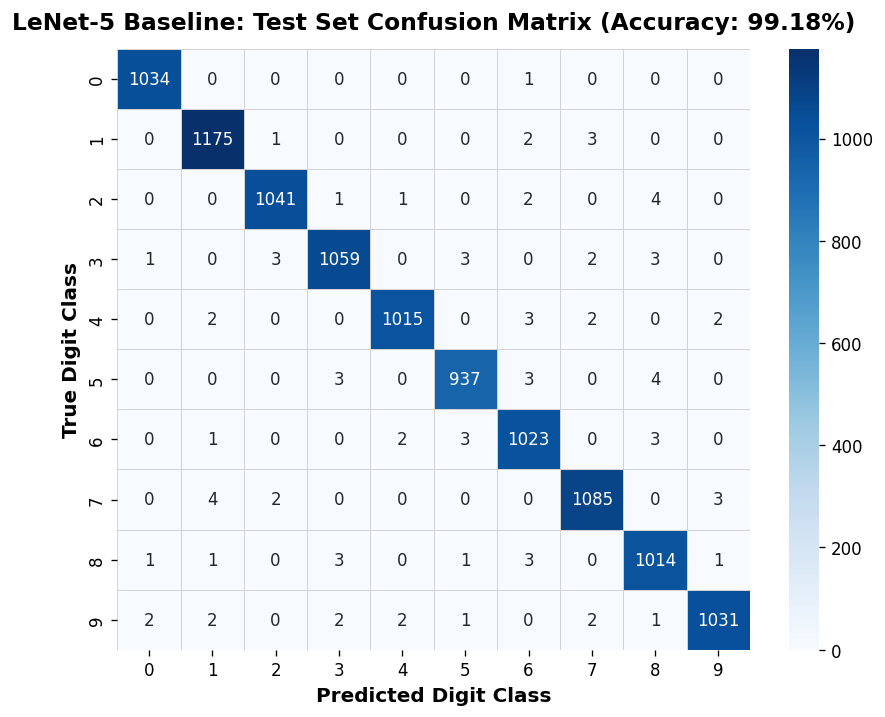

Top 5 Most Frequently Confused Digit Pairs:
  1. True: Digit 7  -->  Pred: Digit 1  (4 times)
  2. True: Digit 5  -->  Pred: Digit 8  (4 times)
  3. True: Digit 2  -->  Pred: Digit 8  (4 times)
  4. True: Digit 7  -->  Pred: Digit 9  (3 times)
  5. True: Digit 8  -->  Pred: Digit 3  (3 times)


In [5]:
y_true = np.load(EMBEDDINGS_DIR / "test_labels.npy")
y_pred = np.load(EMBEDDINGS_DIR / "test_preds.npy")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=range(10), yticklabels=range(10)
)
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.title(f"LeNet-5 Test Confusion Matrix ({accuracy:.2%} Accuracy)")
plt.tight_layout()
plt.show()

pairs = [
    (i, j, cm[i, j])
    for i in range(10)
    for j in range(10)
    if i != j and cm[i, j] > 0
]
pairs.sort(key=lambda x: x[2], reverse=True)

print("Most frequent errors:")
for true_digit, pred_digit, count in pairs[:5]:
    print(f"True {true_digit} -> Pred {pred_digit}: {count}")


## 3. Sample Misclassified Digits

Below are examples of test images that LeNet-5 classified incorrectly.


Total Misclassified Test Samples: 86 out of 10500 (0.82% error rate)



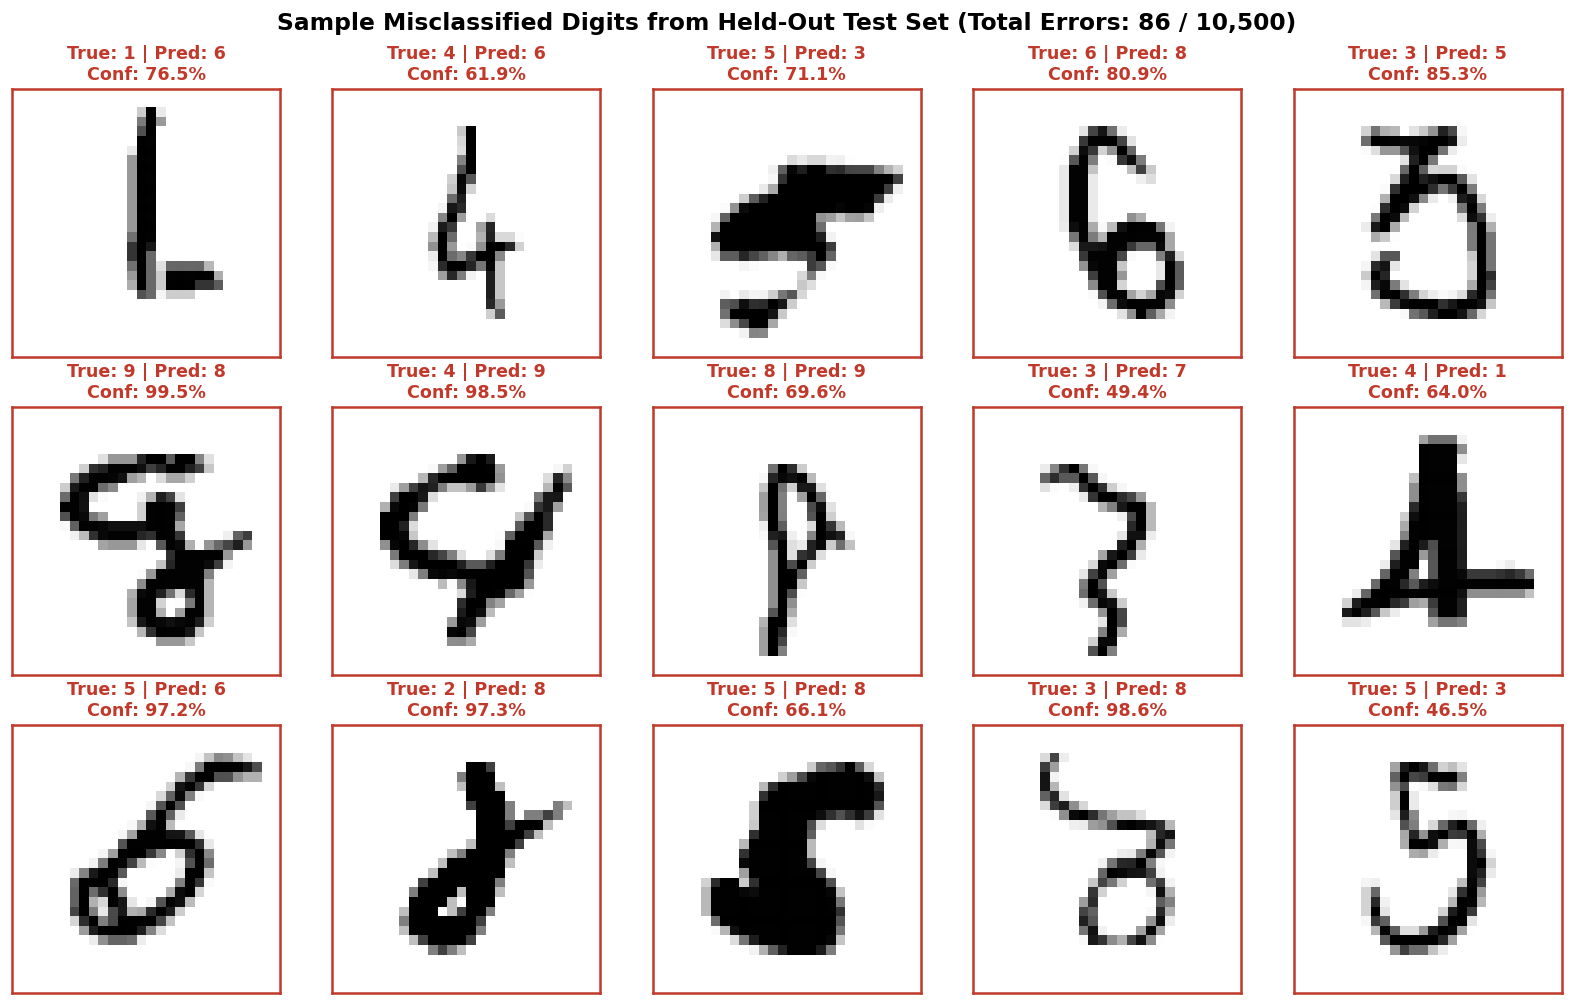

In [6]:
from torchvision.datasets import MNIST

test_correct = np.load(EMBEDDINGS_DIR / "test_correct.npy")
test_conf = np.load(EMBEDDINGS_DIR / "test_confidence.npy")
test_sample_ids = np.load(EMBEDDINGS_DIR / "test_sample_ids.npy")

wrong = np.where(~test_correct)[0]
print(f"Total misclassified test samples: {len(wrong)} / {len(test_correct)}")

# Download/load MNIST in a repository-relative folder.
data_dir = PROJECT_ROOT / "data"
train_mnist = MNIST(root=data_dir, train=True, download=True)
test_mnist = MNIST(root=data_dir, train=False, download=True)
all_images = np.concatenate(
    [train_mnist.data.numpy(), test_mnist.data.numpy()],
    axis=0
)

fig, axes = plt.subplots(3, 5, figsize=(13.5, 8.5))

for ax, test_idx in zip(axes.flat, wrong[:15]):
    sample_id = int(test_sample_ids[test_idx])

    ax.imshow(all_images[sample_id], cmap="gray_r")
    ax.set_title(
        f"True: {y_true[test_idx]} | Pred: {y_pred[test_idx]}\n"
        f"Conf: {test_conf[test_idx]:.1%}",
        fontsize=10
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Sample Misclassified Digits ({len(wrong)} Total Errors)")
plt.tight_layout()
plt.show()


## 4. `fc2` Embeddings

The penultimate `fc2` layer produces an **84-dimensional feature vector** for each image.  
These saved training embeddings will be used as input to the Self-Organizing Map.


Train embeddings: (49000, 84)
Val embeddings  : (10500, 84)
Test embeddings : (10500, 84)
All values finite: True


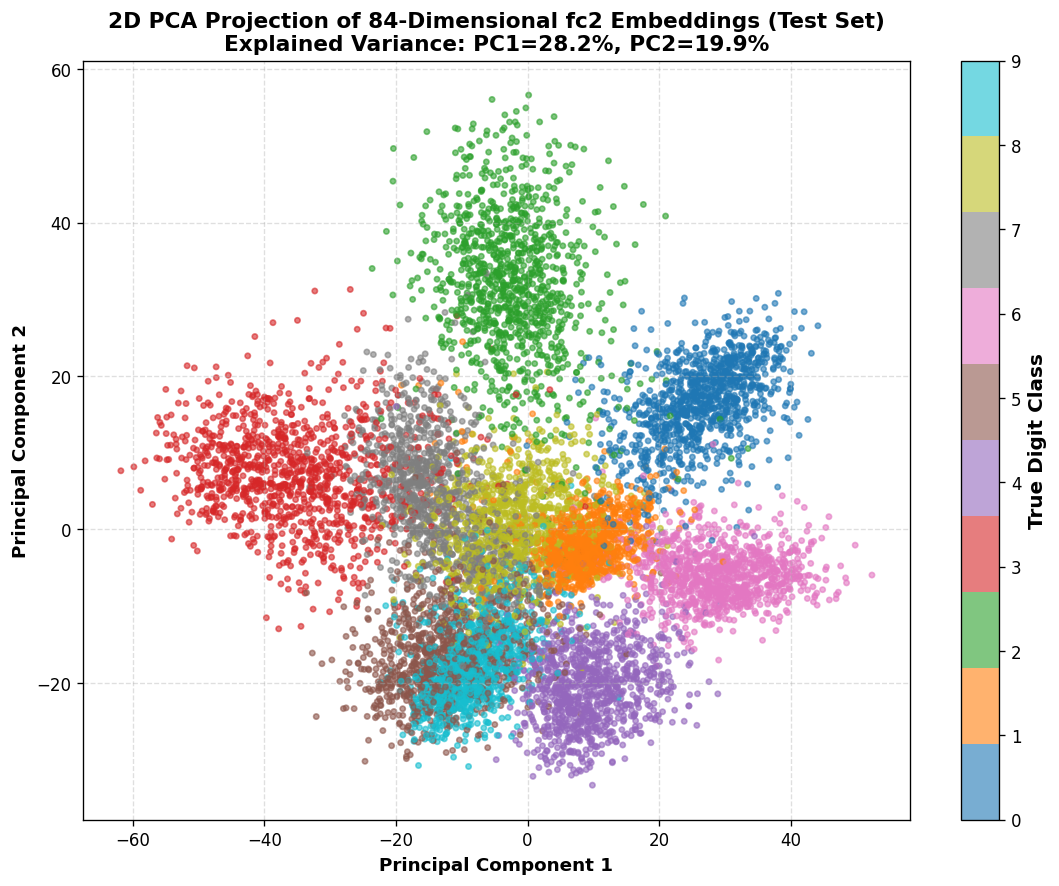

In [7]:
train_emb = np.load(EMBEDDINGS_DIR / "train_features.npy")
val_emb = np.load(EMBEDDINGS_DIR / "val_features.npy")
test_emb = np.load(EMBEDDINGS_DIR / "test_features.npy")

print("Train embeddings:", train_emb.shape)
print("Val embeddings  :", val_emb.shape)
print("Test embeddings :", test_emb.shape)
print("All values finite:", np.isfinite(test_emb).all())

pca = PCA(n_components=2, random_state=42)
test_2d = pca.fit_transform(test_emb)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    test_2d[:, 0],
    test_2d[:, 1],
    c=y_true,
    cmap="tab10",
    alpha=0.65,
    s=12
)
plt.colorbar(scatter, ticks=range(10), label="True Digit")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of 84-D fc2 Test Embeddings")
plt.tight_layout()
plt.show()


## Next Step

Use the **49,000 training `fc2` embeddings** to train and analyze the NNSOM.
